In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("Data/master_dataset.csv", parse_dates=[
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])

In [19]:
df['product_category_name_english'].fillna('Unknown', inplace=True)
df.dropna(subset=['review_score', 'payment_value'], inplace=True)
df['delivery_days'] = (df['order_delivered_customer_date'] - 
                       df['order_purchase_timestamp']).dt.days

df['was_late'] = (df['order_delivered_customer_date'] > 
                  df['order_estimated_delivery_date'])

print(f"Ready: {df.shape}")
print(f"delivery_days check: {df['delivery_days'].mean():.1f} days")
df['delivery_days'] = (df['order_delivered_customer_date'] - 
                       df['order_purchase_timestamp']).dt.days
df['was_late'] = (df['order_delivered_customer_date'] > 
                  df['order_estimated_delivery_date'])

print("Data Loaded!")


total_revenue    = df['payment_value'].sum()
total_orders     = df['order_id'].nunique()
total_customers  = df['customer_unique_id'].nunique()
avg_order_value  = df['payment_value'].mean()
avg_review       = df['review_score'].mean()
avg_delivery     = df['delivery_days'].mean()
late_orders      = df['was_late'].sum()
late_pct         = (late_orders / total_orders) * 100
on_time_pct      = 100 - late_pct

print(f"""
 KEY METRICS SUMMARY

Total Revenue     : BRL {total_revenue:,.0f}
Total Orders      : {total_orders:,}
Total Customers   : {total_customers:,}
Avg Order Value   : BRL {avg_order_value:.2f}
Avg Review Score  : {avg_review:.2f} / 5
Avg Delivery Time : {avg_delivery:.1f} days
On-Time Delivery  : {on_time_pct:.1f}%
Late Orders       : {late_orders:,} ({late_pct:.1f}%)
""")

Ready: (114166, 34)
delivery_days check: 12.0 days
Data Loaded!

 KEY METRICS SUMMARY

Total Revenue     : BRL 19,563,113
Total Orders      : 95,823
Total Customers   : 92,746
Avg Order Value   : BRL 171.36
Avg Review Score  : 4.08 / 5
Avg Delivery Time : 12.0 days
On-Time Delivery  : 90.8%
Late Orders       : 8,818 (9.2%)



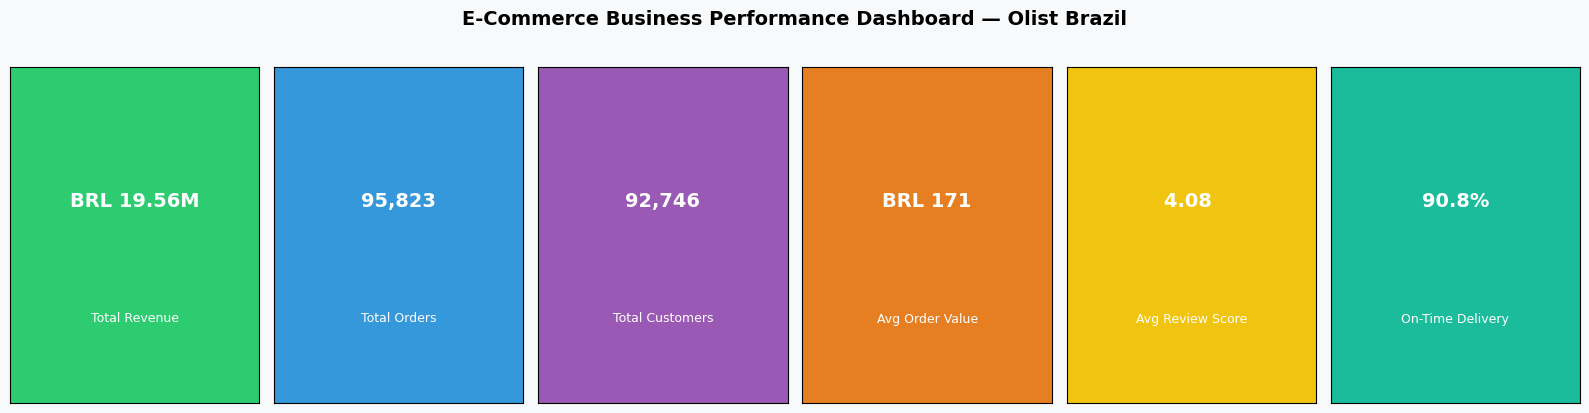

KPI Dashboard done!


In [15]:
fig = plt.figure(figsize=(16, 4))
fig.patch.set_facecolor('#F8F9FA')

kpis = [
    ("Total Revenue",     f"BRL {total_revenue/1e6:.2f}M", "#2ECC71"),
    ("Total Orders",      f"{total_orders:,}",              "#3498DB"),
    ("Total Customers",   f"{total_customers:,}",           "#9B59B6"),
    ("Avg Order Value",   f"BRL {avg_order_value:.0f}",     "#E67E22"),
    ("Avg Review Score",  f"{avg_review:.2f} ",           "#F1C40F"),
    ("On-Time Delivery",  f"{on_time_pct:.1f}%",            "#1ABC9C"),
]

for i, (label, value, color) in enumerate(kpis):
    ax = fig.add_subplot(1, 6, i+1)
    ax.set_facecolor(color)
    ax.text(0.5, 0.6, value, ha='center', va='center',
            fontsize=14, fontweight='bold', color='white',
            transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha='center', va='center',
            fontsize=9, color='white', transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('E-Commerce Business Performance Dashboard — Olist Brazil',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Visuals/kpi_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("KPI Dashboard done!")

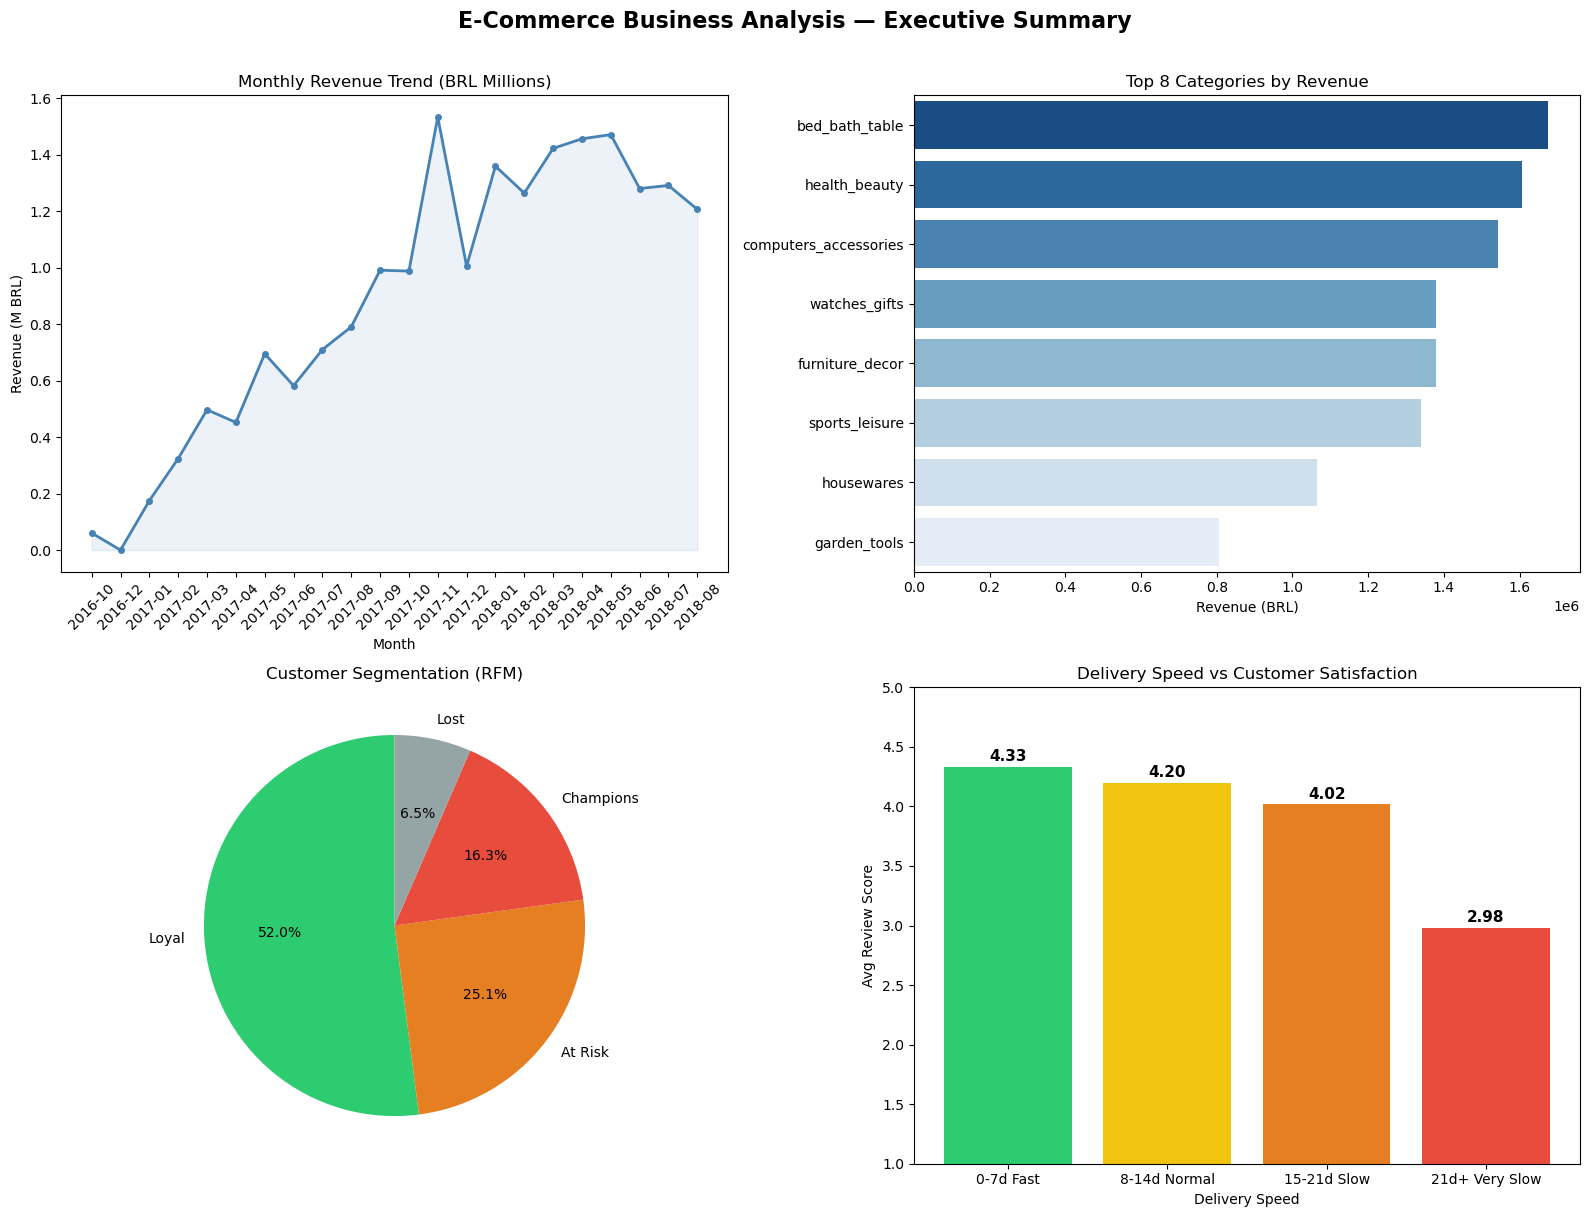

Executive Summary Chart done!


In [20]:
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')
monthly_rev = df.groupby('order_month')['payment_value']\
                .sum().reset_index()
monthly_rev['order_month'] = monthly_rev['order_month'].astype(str)

top_cat = df.groupby('product_category_name_english')['payment_value']\
            .sum().sort_values(ascending=False).head(8).reset_index()

snapshot_date = df['order_purchase_timestamp'].max()
rfm = df.groupby('customer_unique_id').agg(
    Recency   = ('order_purchase_timestamp',
                  lambda x: (snapshot_date - x.max()).days),
    Frequency = ('order_id', 'nunique'),
    Monetary  = ('payment_value', 'sum')
).reset_index()
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'),
                          q=4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1,2,3,4])
rfm['RFM_Score'] = (rfm['R_Score'].astype(int) +
                    rfm['F_Score'].astype(int) +
                    rfm['M_Score'].astype(int))
def segment(score):
    if score >= 10: return 'Champions'
    elif score >= 7: return 'Loyal'
    elif score >= 5: return 'At Risk'
    else: return 'Lost'
rfm['Segment'] = rfm['RFM_Score'].apply(segment)

delivery_bucket_avg = df[df['delivery_days']>0].copy()
def dbucket(d):
    if d<=7: return '0-7d Fast'
    elif d<=14: return '8-14d Normal'
    elif d<=21: return '15-21d Slow'
    else: return '21d+ Very Slow'
delivery_bucket_avg['bucket'] = delivery_bucket_avg['delivery_days'].apply(dbucket)
bkt_order = ['0-7d Fast','8-14d Normal','15-21d Slow','21d+ Very Slow']
dr = delivery_bucket_avg.groupby('bucket')['review_score']\
                         .mean().reindex(bkt_order).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('E-Commerce Business Analysis — Executive Summary',
             fontsize=16, fontweight='bold', y=1.01)
axes[0,0].plot(monthly_rev['order_month'],
               monthly_rev['payment_value']/1e6,
               marker='o', color='steelblue', linewidth=2, markersize=4)
axes[0,0].set_title('Monthly Revenue Trend (BRL Millions)', fontsize=12)
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Revenue (M BRL)')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].fill_between(range(len(monthly_rev)),
                        monthly_rev['payment_value']/1e6,
                        alpha=0.1, color='steelblue')

sns.barplot(data=top_cat, x='payment_value', 
            y='product_category_name_english',
            palette='Blues_r', ax=axes[0,1])
axes[0,1].set_title('Top 8 Categories by Revenue', fontsize=12)
axes[0,1].set_xlabel('Revenue (BRL)')
axes[0,1].set_ylabel('')

seg_counts = rfm['Segment'].value_counts()
colors_seg = ['#2ECC71','#E67E22','#E74C3C','#95A5A6']
axes[1,0].pie(seg_counts.values,
              labels=seg_counts.index,
              autopct='%1.1f%%',
              colors=colors_seg,
              startangle=90)
axes[1,0].set_title('Customer Segmentation (RFM)', fontsize=12)

bars = axes[1,1].bar(dr['bucket'], dr['review_score'],
                     color=['#2ECC71','#F1C40F','#E67E22','#E74C3C'])
axes[1,1].set_title('Delivery Speed vs Customer Satisfaction', fontsize=12)
axes[1,1].set_xlabel('Delivery Speed')
axes[1,1].set_ylabel('Avg Review Score')
axes[1,1].set_ylim(1, 5)
for bar, val in zip(bars, dr['review_score']):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.05,
                   f'{val:.2f}', ha='center',
                   fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('Visuals/executive_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Executive Summary Chart done!")

In [12]:
print("""

         E-COMMERCE BUSINESS ANALYSIS — FINAL REPORT             
                    Olist Brazil Dataset                          

  Dataset   : 115,030 orders | 2016-2018                         
  Analyst   : [Your Name]                                         
  Tools     : Python, Pandas, NumPy, Matplotlib, Seaborn         



* KEY FINDINGS


1. REVENUE GROWTH
   Business grew consistently from 2016 to 2017
   Peak revenue in Nov 2017 (~1.5M BRL) — Black Friday effect
   Stable at 1.2M-1.4M BRL monthly in 2018

2. PRODUCT PERFORMANCE  
   Top 3 categories: Bed/Bath/Table, Health/Beauty, Computers
   Only 17 out of 70+ categories = 80% of total revenue (Pareto)
   Bottom 50+ categories need marketing investment or removal

3. CUSTOMER ANALYSIS
   52% customers are Loyal — strong retention base
   25% customers are At Risk — need re-engagement campaigns
   6% customers are Lost — win-back campaigns needed

4. DELIVERY PERFORMANCE
   92% orders delivered on time
   7,660 late orders scored avg 2.5/5 vs 4.2/5 for on-time
   Max delivery: 208 days — extreme outlier cases exist
   Delivery speed is the #1 driver of customer satisfaction

5. PAYMENT INSIGHTS
   73% customers prefer credit card
   Boleto at 19% — important for non-card customers


 BUSINESS RECOMMENDATIONS:


REC 1 — IMPROVE DELIVERY SPEED [HIGH PRIORITY]
   * Late deliveries score 2.5/5 vs 4.2/5 for on-time orders
   * Reducing late deliveries by 50% could significantly
     improve overall rating from 4.08 to 4.3+
   * Focus on logistics partners in non-SP states

REC 2 — RE-ENGAGE AT-RISK CUSTOMERS [HIGH PRIORITY]  
   * 23,302 customers are at risk of churning
   * Launch email/discount campaigns targeting this segment
   * Even 20% retention = ~4,600 customers saved

REC 3 — DOUBLE DOWN ON TOP CATEGORIES [MEDIUM PRIORITY]
   * Bed/Bath/Table + Health/Beauty = top revenue drivers
   * Increase inventory and seller recruitment in these areas
   * Run targeted promotions during peak months (Nov/Dec)

REC 4 — EXPAND IN TOP STATES [MEDIUM PRIORITY]
   * SP generates 3x more than RJ — already dominant
   * Focus growth investment on RJ, MG, RS for expansion
   * These states show growth potential

REC 5 — BLACK FRIDAY STRATEGY [SEASONAL]
   * Nov 2017 showed massive spike — replicate annually
   * Plan inventory and logistics 2 months in advance
   * Offer credit card exclusive deals (73% of users)
""")



         E-COMMERCE BUSINESS ANALYSIS — FINAL REPORT             
                    Olist Brazil Dataset                          

  Dataset   : 115,030 orders | 2016-2018                         
  Analyst   : [Your Name]                                         
  Tools     : Python, Pandas, NumPy, Matplotlib, Seaborn         



* KEY FINDINGS


1. REVENUE GROWTH
   Business grew consistently from 2016 to 2017
   Peak revenue in Nov 2017 (~1.5M BRL) — Black Friday effect
   Stable at 1.2M-1.4M BRL monthly in 2018

2. PRODUCT PERFORMANCE  
   Top 3 categories: Bed/Bath/Table, Health/Beauty, Computers
   Only 17 out of 70+ categories = 80% of total revenue (Pareto)
   Bottom 50+ categories need marketing investment or removal

3. CUSTOMER ANALYSIS
   52% customers are Loyal — strong retention base
   25% customers are At Risk — need re-engagement campaigns
   6% customers are Lost — win-back campaigns needed

4. DELIVERY PERFORMANCE
   92% orders delivered on time
   7,660 late or

In [11]:
summary_data = {
    'Metric': [
        'Total Revenue', 'Total Orders', 'Total Customers',
        'Avg Order Value', 'Avg Review Score', 'Avg Delivery Days',
        'On-Time Delivery %', 'Late Orders', 'Top Category',
        'Top State', 'Loyal Customers %', 'At Risk Customers %'
    ],
    'Value': [
        f'BRL {total_revenue:,.0f}',
        f'{total_orders:,}',
        f'{total_customers:,}',
        f'BRL {avg_order_value:.2f}',
        f'{avg_review:.2f} / 5',
        f'{avg_delivery:.1f} days',
        f'{on_time_pct:.1f}%',
        f'{late_orders:,} ({late_pct:.1f}%)',
        'Bed, Bath & Table',
        'Sao Paulo (SP)',
        '52%',
        '25%'
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('final_summary.csv', index=False)

print("Final summary saved!")
print("\n" + summary_df.to_string(index=False))

Final summary saved!

             Metric             Value
      Total Revenue    BRL 19,563,113
       Total Orders            95,823
    Total Customers            92,746
    Avg Order Value        BRL 171.36
   Avg Review Score          4.08 / 5
  Avg Delivery Days         12.0 days
 On-Time Delivery %             90.8%
        Late Orders      8,818 (9.2%)
       Top Category Bed, Bath & Table
          Top State    Sao Paulo (SP)
  Loyal Customers %               52%
At Risk Customers %               25%
